In [17]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
zip_path = "/content/drive/MyDrive/Global_Oral.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
train_path = "/content/data/train"
val_path   = "/content/data/valid"
test_path  = "/content/data/test"

train_data = datasets.ImageFolder(train_path, transform=transform)
val_data   = datasets.ImageFolder(val_path, transform=transform)
test_data  = datasets.ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 61.2MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
import os
import json

checkpoint_path = "/content/drive/MyDrive/resnet_checkpoint.pth"
metrics_path = "/content/drive/MyDrive/resnet_metrics.json"

start_epoch = 0
history = {"loss": [], "accuracy": []}

In [ ]:
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch'] + 1

    print(f"Resuming from epoch {start_epoch}")

if os.path.exists(metrics_path):
    with open(metrics_path, "r") as f:
        history = json.load(f)

Resuming from epoch 1


In [ ]:
epochs = 20

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    history["loss"].append(epoch_loss)
    history["accuracy"].append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # 🔥 SAVE CHECKPOINT EVERY EPOCH
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }, checkpoint_path)

    # 🔥 SAVE METRICS JSON
    with open(metrics_path, "w") as f:
        json.dump(history, f)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2/20 | Loss: 0.0342 | Acc: 0.9918
Epoch 3/20 | Loss: 0.0122 | Acc: 0.9979
Epoch 4/20 | Loss: 0.0135 | Acc: 0.9961
Epoch 5/20 | Loss: 0.0109 | Acc: 0.9982
Epoch 6/20 | Loss: 0.0155 | Acc: 0.9933
Epoch 7/20 | Loss: 0.0168 | Acc: 0.9943
Epoch 8/20 | Loss: 0.0273 | Acc: 0.9894
Epoch 9/20 | Loss: 0.0262 | Acc: 0.9918
Epoch 10/20 | Loss: 0.0312 | Acc: 0.9876
Epoch 11/20 | Loss: 0.0135 | Acc: 0.9958
Epoch 12/20 | Loss: 0.0115 | Acc: 0.9964
Epoch 13/20 | Loss: 0.0066 | Acc: 0.9970
Epoch 14/20 | Loss: 0.0051 | Acc: 0.9982
Epoch 15/20 | Loss: 0.0029 | Acc: 0.9991
Epoch 16/20 | Loss: 0.0031 | Acc: 0.9985
Epoch 17/20 | Loss: 0.0031 | Acc: 0.9985
Epoch 18/20 | Loss: 0.0027 | Acc: 0.9988
Epoch 19/20 | Loss: 0.0024 | Acc: 0.9985
Epoch 20/20 | Loss: 0.0019 | Acc: 0.9991


In [ ]:
import json

with open("/content/drive/MyDrive/resnet_metrics.json", "r") as f:
    history = json.load(f)

for i in range(len(history["loss"])):
    print(f"Epoch {i+1} | Loss: {history['loss'][i]:.4f} | Acc: {history['accuracy'][i]:.4f}")

Epoch 1 | Loss: 0.2007 | Acc: 0.9187
Epoch 2 | Loss: 0.0342 | Acc: 0.9918
Epoch 3 | Loss: 0.0122 | Acc: 0.9979
Epoch 4 | Loss: 0.0135 | Acc: 0.9961
Epoch 5 | Loss: 0.0109 | Acc: 0.9982
Epoch 6 | Loss: 0.0155 | Acc: 0.9933
Epoch 7 | Loss: 0.0168 | Acc: 0.9943
Epoch 8 | Loss: 0.0273 | Acc: 0.9894
Epoch 9 | Loss: 0.0262 | Acc: 0.9918
Epoch 10 | Loss: 0.0312 | Acc: 0.9876
Epoch 11 | Loss: 0.0135 | Acc: 0.9958
Epoch 12 | Loss: 0.0115 | Acc: 0.9964
Epoch 13 | Loss: 0.0066 | Acc: 0.9970
Epoch 14 | Loss: 0.0051 | Acc: 0.9982
Epoch 15 | Loss: 0.0029 | Acc: 0.9991
Epoch 16 | Loss: 0.0031 | Acc: 0.9985
Epoch 17 | Loss: 0.0031 | Acc: 0.9985
Epoch 18 | Loss: 0.0027 | Acc: 0.9988
Epoch 19 | Loss: 0.0024 | Acc: 0.9985
Epoch 20 | Loss: 0.0019 | Acc: 0.9991


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def get_preds(loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

y_val, y_val_pred = get_preds(val_loader)
y_test, y_test_pred = get_preds(test_loader)

In [ ]:
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)  # sensitivity
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    return acc, precision, recall, specificity, f1

acc, precision, recall, specificity, f1 = get_metrics(y_test, y_test_pred)

print("Accuracy:", acc)
print("Precision:", precision)
print("Sensitivity (Recall):", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)

Accuracy: 0.9806763285024155
Precision: 0.9853658536585366
Sensitivity (Recall): 0.9758454106280193
Specificity: 0.9855072463768116
F1 Score: 0.9805825242718447


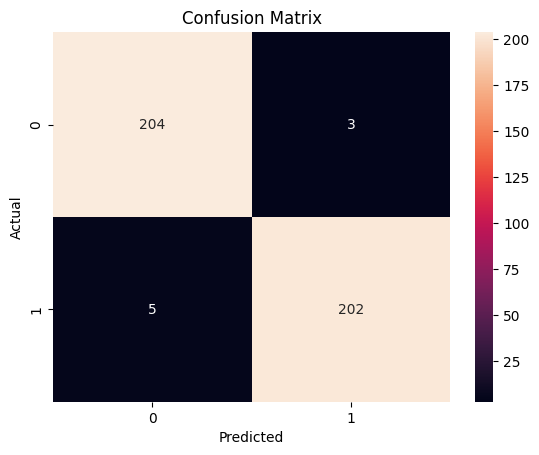

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

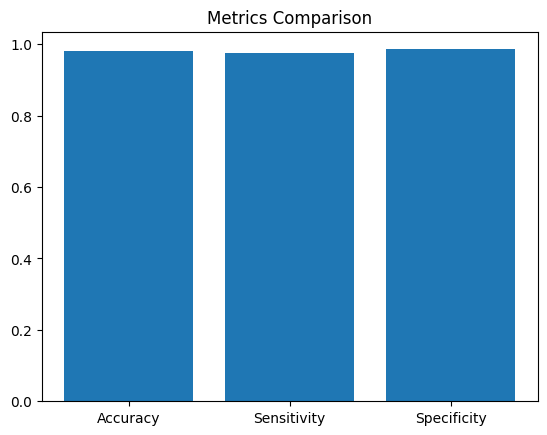

In [ ]:
metrics_names = ["Accuracy", "Sensitivity", "Specificity"]
values = [acc, recall, specificity]

plt.figure()
plt.bar(metrics_names, values)
plt.title("Metrics Comparison")
plt.show()

In [ ]:
import json

with open("/content/drive/MyDrive/resnet_metrics.json", "r") as f:
    history = json.load(f)

loss = history["loss"]
accuracy = history["accuracy"]

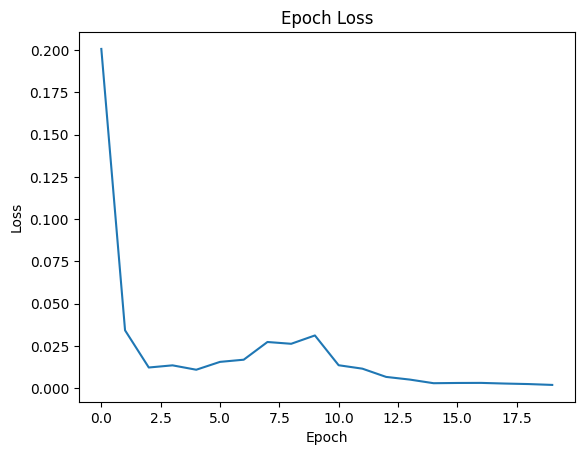

In [ ]:
plt.figure()
plt.plot(loss)
plt.title("Epoch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

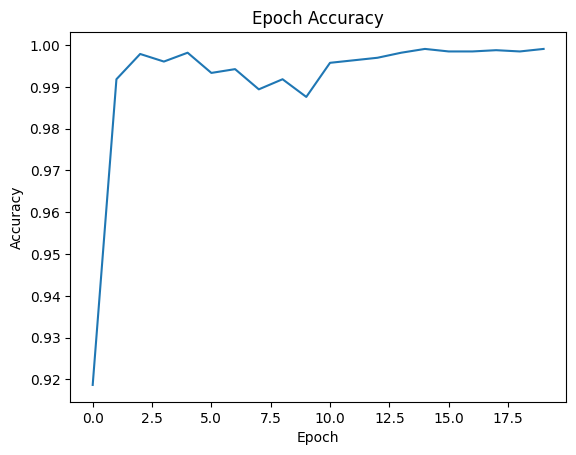

In [ ]:
plt.figure()
plt.plot(accuracy)
plt.title("Epoch Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

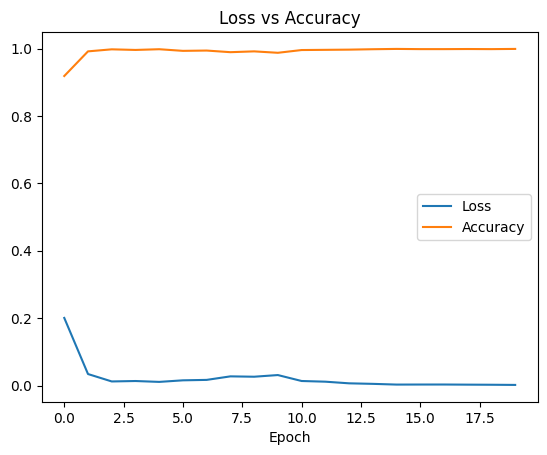

In [ ]:
plt.figure()
plt.plot(loss, label="Loss")
plt.plot(accuracy, label="Accuracy")
plt.legend()
plt.title("Loss vs Accuracy")
plt.xlabel("Epoch")
plt.show()

In [ ]:
import os, json, torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

SAVE_DIR = "/content/drive/MyDrive/ResNet_Final/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- 1. SAVE FINAL MODEL ----------
torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict()
}, SAVE_DIR + "final_model.pth")

# ---------- 2. LOAD HISTORY ----------
with open("/content/drive/MyDrive/resnet_metrics.json", "r") as f:
    history = json.load(f)

# ---------- 3. GET PREDICTIONS ----------
def get_preds(loader):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_preds(test_loader)

# ---------- 4. METRICS ----------
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)

metrics = {
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "specificity": specificity,
    "f1_score": f1
}

# SAVE METRICS JSON
with open(SAVE_DIR + "final_metrics.json", "w") as f:
    json.dump(metrics, f)

print(metrics)

# ---------- 5. SAVE CONFUSION MATRIX IMAGE ----------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.savefig(SAVE_DIR + "confusion_matrix.png")
plt.close()

# ---------- 6. SAVE BAR GRAPH ----------
plt.figure()
plt.bar(["Accuracy","Sensitivity","Specificity"], [acc, recall, specificity])
plt.title("Metrics")
plt.savefig(SAVE_DIR + "metrics_bar.png")
plt.close()

# ---------- 7. SAVE TRAINING GRAPHS ----------
loss = history["loss"]
accuracy = history["accuracy"]

# Loss graph
plt.figure()
plt.plot(loss)
plt.title("Epoch Loss")
plt.savefig(SAVE_DIR + "loss.png")
plt.close()

# Accuracy graph
plt.figure()
plt.plot(accuracy)
plt.title("Epoch Accuracy")
plt.savefig(SAVE_DIR + "accuracy.png")
plt.close()

# Combined graph
plt.figure()
plt.plot(loss, label="Loss")
plt.plot(accuracy, label="Accuracy")
plt.legend()
plt.title("Loss vs Accuracy")
plt.savefig(SAVE_DIR + "combined.png")
plt.close()

# ---------- 8. SAVE PREDICTIONS ----------
np.save(SAVE_DIR + "y_true.npy", y_true)
np.save(SAVE_DIR + "y_pred.npy", y_pred)

print("🔥 EVERYTHING SAVED SUCCESSFULLY")

{'accuracy': 0.9806763285024155, 'precision': 0.9853658536585366, 'recall': 0.9758454106280193, 'specificity': np.float64(0.9855072463768116), 'f1_score': 0.9805825242718447}
🔥 EVERYTHING SAVED SUCCESSFULLY


✅ Model Loaded Successfully


Saving 106.jpeg to 106 (1).jpeg


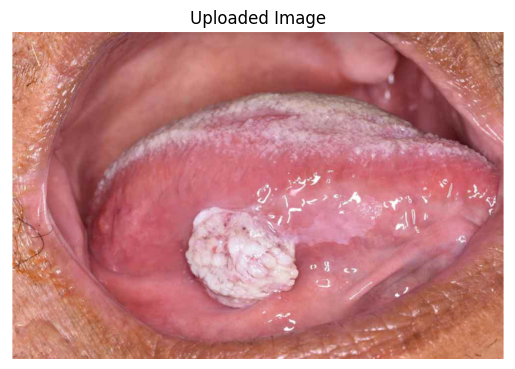

🩺 Prediction: Cancer
🔥 Confidence: 1.0000


In [9]:
# ==============================
# RECOVER MODEL + TEST RANDOM IMAGE
# Upload image in Colab terminal/notebook and predict
# ==============================

import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# ---------- DEVICE ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- PATH ----------
MODEL_PATH = "/content/drive/MyDrive/ResNet_Final/ResNet_Final.pth"

# ---------- LOAD MODEL ----------
model = models.resnet18(pretrained=False)   # change to resnet50 if you trained resnet50
model.fc = nn.Linear(model.fc.in_features, 2)   # 2 classes

checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model'])
model = model.to(device)
model.eval()

print("✅ Model Loaded Successfully")

# ---------- CLASS NAMES ----------
class_names = ["Cancer", "Control"]   # change order if your dataset order is different

# ---------- TRANSFORM ----------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ---------- UPLOAD IMAGE ----------
uploaded = files.upload()

# ---------- PREDICT ----------
for file_name in uploaded.keys():
    img = Image.open(file_name).convert("RGB")

    plt.imshow(img)
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    image = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    predicted_class = class_names[pred.item()]
    confidence = conf.item()

    print(f"🩺 Prediction: {predicted_class}")
    print(f"🔥 Confidence: {confidence:.4f}")

In [16]:
import os
import torch

# Folder path
SAVE_DIR = "/content/drive/MyDrive/ResNet_Final/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save only model weights (.pth)
torch.save(model.state_dict(), SAVE_DIR + "RESNET_final.pth")

print("✅ Model saved successfully at:")
print(SAVE_DIR + "RESNET_final.pth")

✅ Model saved successfully at:
/content/drive/MyDrive/ResNet_Final/RESNET_final.pth
